# What Is a Neural Network?

Build intuition for neurons, layers, and a simple feed-forward network using Keras.

Estimated time: 20 minutes

How to use: run top-to-bottom

## Learning objectives
- Understand the basic structure of a neural network.
- Relate biological neurons to artificial ones.
- Draw a simple neural network architecture.
- Quiz on NN components.

## 1) Setup
Imports, a fixed seed, and a simple network-drawing helper.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

def quick_summary(df, name):
    print(f"{name} shape: {df.shape}")
    print(df.head())
    print()

def draw_network(layer_sizes):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.axis("off")
    max_neurons = max(layer_sizes)
    for layer_idx, layer_size in enumerate(layer_sizes):
        y_positions = np.linspace(0, 1, layer_size)
        x = layer_idx / (len(layer_sizes) - 1)
        for y in y_positions:
            ax.scatter(x, y, s=200, edgecolors="k", facecolors="white")
        if layer_idx > 0:
            prev_size = layer_sizes[layer_idx - 1]
            prev_y = np.linspace(0, 1, prev_size)
            for y_prev in prev_y:
                for y in y_positions:
                    ax.plot([x - 1 / (len(layer_sizes) - 1), x], [y_prev, y], color="#999999", linewidth=1)
    plt.title("Simple Neural Network")
    plt.show()

print("Setup complete ✅")

Setup complete ✅


## 2) Tiny data / inputs for today's topics
We will create a small binary dataset where inputs map to a yes/no output (like a neuron firing).

In [25]:
n = 1000
stim_1 = np.random.normal(0, 1, n)
stim_2 = np.random.normal(0, 1, n)
noise = np.random.normal(0, 0.4, n)
firing = (stim_1 + stim_2 + noise > 0).astype(int)

df = pd.DataFrame({
    "stimulus_1": stim_1,
    "stimulus_2": stim_2,
    "fires": firing
})

quick_summary(df, "df")
print("fire rate:", round(df["fires"].mean(), 3))
print(df.describe().T)

df shape: (1000, 3)
   stimulus_1  stimulus_2  fires
0    0.496714    1.399355      1
1   -0.138264    0.924634      1
2    0.647689    0.059630      1
3    1.523030   -0.646937      1
4   -0.234153    0.698223      0

fire rate: 0.516
             count      mean       std       min       25%       50%  \
stimulus_1  1000.0  0.019332  0.979216 -3.241267 -0.647590  0.025301   
stimulus_2  1000.0  0.070836  0.997454 -2.940389 -0.606242  0.063077   
fires       1000.0  0.516000  0.499994  0.000000  0.000000  1.000000   

                 75%       max  
stimulus_1  0.647944  3.852731  
stimulus_2  0.728882  3.193108  
fires       1.000000  1.000000  


## 3) Main task (guided)
Define a tiny neural network and train it briefly to see the structure in action.

In [26]:
# TODO 1: set input dimension
input_dim = 2

# TODO 2: choose hidden units
hidden_units = 30

# TODO 3: choose hidden activation (e.g., 'relu')
hidden_activation = "relu"

# TODO 4: choose output activation for binary classification
output_activation = "sigmoid"

# TODO 5: set a small number of epochs
epochs = 15

X = df[["stimulus_1", "stimulus_2"]].values
y = df["fires"].values

model = Sequential([
    Dense(hidden_units, activation=hidden_activation, input_shape=(input_dim,)),
    Dense(1, activation=output_activation),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X, y, epochs=epochs, verbose=0)

print("Final training accuracy:", round(float(history.history["accuracy"][-1]), 3))

# Increased the number of training samples from 120 to 1000
# to give the neural network more data to learn from.
# Also increased the number of neurons to 30 and trained for 15 epochs
# to improve learning stability and make the model accuracy more consistent.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training accuracy: 0.902


## 4) Verify / evaluate
Inspect the model, check prediction shapes, and draw the architecture.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 30)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365 (1.43 KB)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 244 (980.00 B)

Predictions shape: (5, 1)
Predictions head: [0.994 0.939 0.916 0.905 0.859]


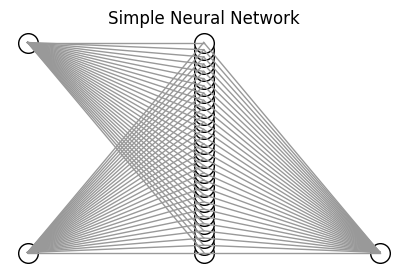

Interpretation: inputs feed into hidden units, then into an output neuron.


In [27]:
model.summary()

preds = model.predict(X[:5], verbose=0)
print("Predictions shape:", preds.shape)
print("Predictions head:", np.round(preds.flatten(), 3))

if output_activation == "sigmoid":
    assert np.all((preds >= 0) & (preds <= 1)), "Sigmoid outputs must be in [0, 1]."

draw_network([input_dim, hidden_units, 1])

print("Interpretation: inputs feed into hidden units, then into an output neuron.")

## 5) Common pitfall + fix
Pitfall: forgetting a sigmoid on the output for binary classification. Fix: apply sigmoid to produce probabilities.

In [28]:
logits = np.array([-2.0, 0.0, 2.0])
y_true = np.array([0.0, 1.0, 1.0])

wrong_pred = logits
correct_pred = 1 / (1 + np.exp(-logits))

wrong_loss = tf.keras.losses.binary_crossentropy(y_true, wrong_pred).numpy()
correct_loss = tf.keras.losses.binary_crossentropy(y_true, correct_pred).numpy()

print("Wrong preds (logits):", np.round(wrong_pred, 3))
print("Correct preds (sigmoid):", np.round(correct_pred, 3))
print("Loss with logits (wrong):", np.round(wrong_loss, 3))
print("Loss with sigmoid (correct):", np.round(correct_loss, 3))
print("Fix: use a sigmoid output for binary classification probabilities.")

Wrong preds (logits): [-2.  0.  2.]
Correct preds (sigmoid): [0.119 0.5   0.881]
Loss with logits (wrong): 5.373
Loss with sigmoid (correct): 0.316
Fix: use a sigmoid output for binary classification probabilities.
